|컬럼 이름|컬럼 정보|값|
|---|---|---|
|Time_spent_Alone|매일 혼자 보낸 시간 |(0-11시간)|
|Stage_fear|스테이지 공포의 존재|(Yes/No)|
|Social_event_attendance|사회적 사건의 빈도|(0–10)|
|Going_outside|외출 빈도|(0–7)|
|Drained_after_socializing|사교 후 피로감을 느낍니다|(Yes/No)|
|Friends_circle_size|친한 친구의 수|(0–15)|
|Post_frequency|소셜 미디어 포스트 빈도|(0–10)|
|Personality|목표 변수|(Extrovert/Introvert)|

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

from sklearn.preprocessing import LabelEncoder
from sklearn.impute import  SimpleImputer

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split, RandomizedSearchCV


In [2]:
df = pd.read_csv('data/personality_dataset.csv', encoding='utf-8')
original_df = df.copy()

In [3]:
df

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert
...,...,...,...,...,...,...,...,...
2895,3.0,No,7.0,6.0,No,6.0,6.0,Extrovert
2896,3.0,No,8.0,3.0,No,14.0,9.0,Extrovert
2897,4.0,Yes,1.0,1.0,Yes,4.0,0.0,Introvert
2898,11.0,Yes,1.0,NaN,Yes,2.0,0.0,Introvert


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2900 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2837 non-null   float64
 1   Stage_fear                 2827 non-null   str    
 2   Social_event_attendance    2838 non-null   float64
 3   Going_outside              2834 non-null   float64
 4   Drained_after_socializing  2848 non-null   str    
 5   Friends_circle_size        2823 non-null   float64
 6   Post_frequency             2835 non-null   float64
 7   Personality                2900 non-null   str    
dtypes: float64(5), str(3)
memory usage: 181.4 KB


In [5]:
nf = []
cf = []
features = df.columns
for col in features:
    if df[col].dtype in ['float64', 'int64', 'float32', 'int32']:
        nf.append(col)
    else:
        cf.append(col)
print(nf)
print(cf)

['Time_spent_Alone', 'Social_event_attendance', 'Going_outside', 'Friends_circle_size', 'Post_frequency']
['Stage_fear', 'Drained_after_socializing', 'Personality']


In [6]:
target = 'Personality'
df[target].value_counts()

Personality
Extrovert    1491
Introvert    1409
Name: count, dtype: int64

In [7]:
df.isnull().sum()

Time_spent_Alone             63
Stage_fear                   73
Social_event_attendance      62
Going_outside                66
Drained_after_socializing    52
Friends_circle_size          77
Post_frequency               65
Personality                   0
dtype: int64

In [8]:
personality_counts = df[target].value_counts()

personality_percentage = df['Personality'].value_counts(normalize=True) * 100

for class_val, percentage in personality_percentage.items():
    print(f'클래스: {class_val}, 비율: {percentage:.4f}')

클래스: Extrovert, 비율: 51.4138
클래스: Introvert, 비율: 48.5862


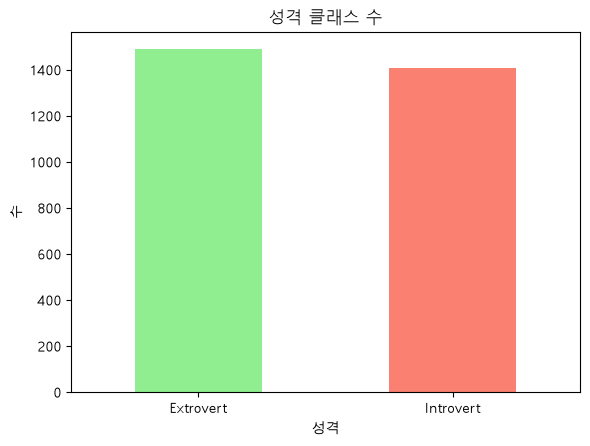

In [9]:
plt.figure(figsize=(6, 5))
personality_counts.plot(kind='bar', color=['lightgreen', 'salmon'])
plt.title('성격 클래스 수')
plt.xlabel('성격')
plt.ylabel('수')
plt.tight_layout()
plt.xticks(rotation=0)
plt.show()

In [10]:
df[nf].describe().T

,count,mean,std,min,25%,50%,75%,max
Time_spent_Alone,2837.0,4.505816,3.479192,0.0,2.0,4.0,8.0,11.0
Social_event_attendance,2838.0,3.963354,2.903827,0.0,2.0,3.0,6.0,10.0
Going_outside,2834.0,3.000000,2.247327,0.0,1.0,3.0,5.0,7.0
Friends_circle_size,2823.0,6.268863,4.289693,0.0,3.0,5.0,10.0,15.0
Post_frequency,2835.0,3.564727,2.926582,0.0,1.0,3.0,6.0,10.0


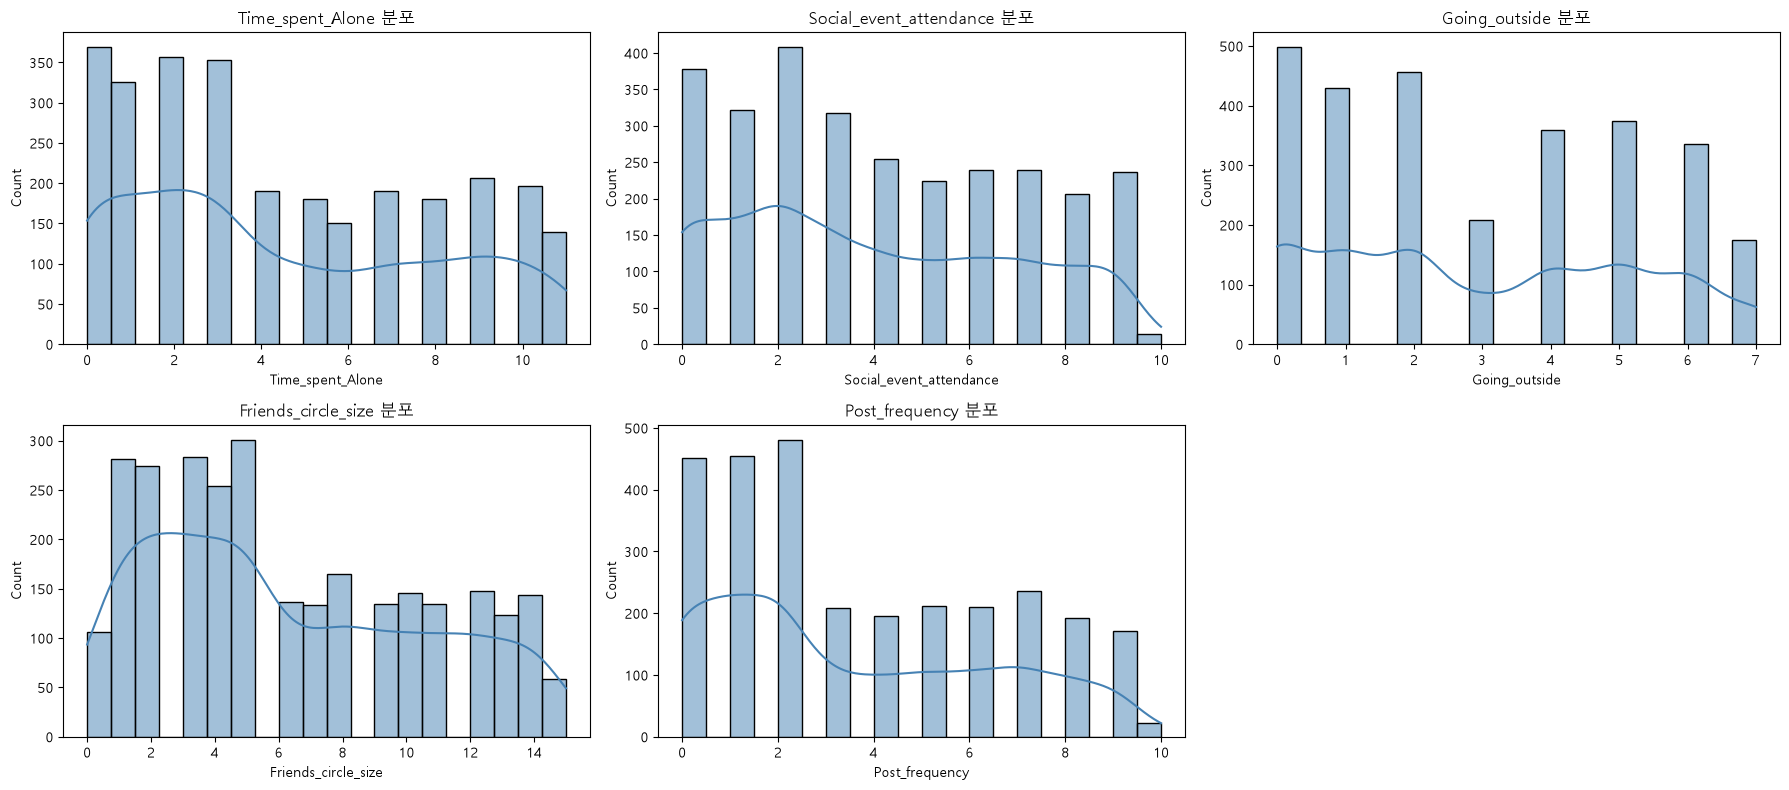

In [11]:
n_cols = 3
n_features = len(nf)
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(nf):
    sns.histplot(
        df[col].dropna(),
        bins=20,
        kde=True,
        ax=axes[i],
        color='steelblue'
    )
    axes[i].set_title(f'{col} 분포')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

for j in range(i+ 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

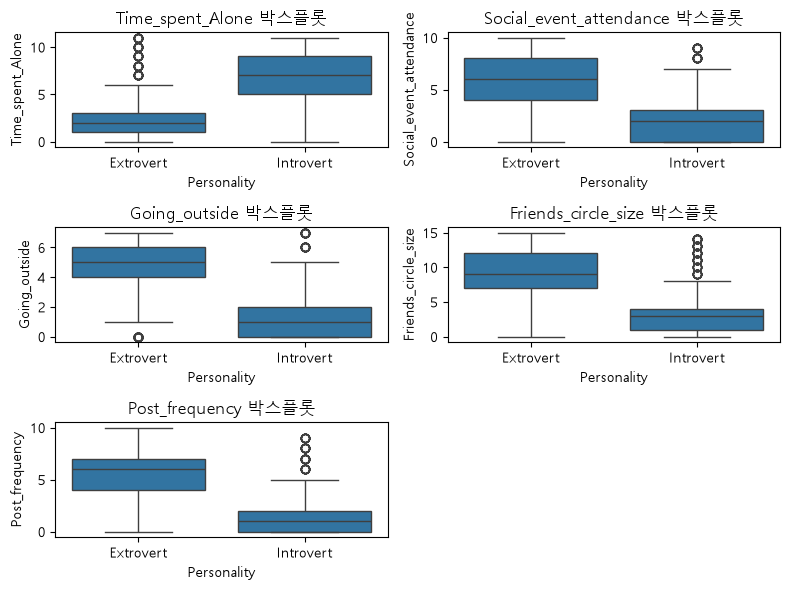

In [12]:
plt.figure(figsize=(8, 6))

for i, col in enumerate(nf, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(x=target, y=col, data=df)
    plt.title(f'{col} 박스플롯')

plt.tight_layout()
plt.show()

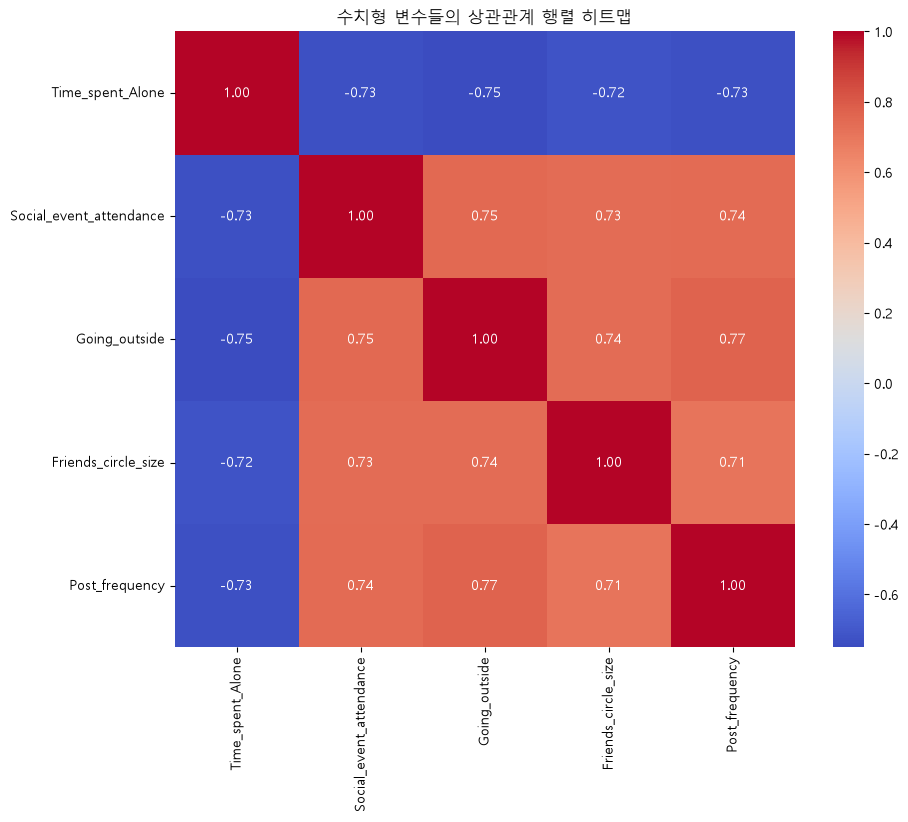

In [13]:
plt.figure(figsize=(10, 8))

corr_matrix = df[nf].corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('수치형 변수들의 상관관계 행렬 히트맵')
plt.show()

In [14]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

vif_df = df[nf].copy()
vif_df = vif_df.dropna()

vif_data = add_constant(vif_df)
vif_data

,const,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
0,1.0,4.0,4.0,6.0,13.0,5.0
1,1.0,9.0,0.0,0.0,0.0,3.0
2,1.0,9.0,1.0,2.0,5.0,2.0
3,1.0,0.0,6.0,7.0,14.0,8.0
4,1.0,3.0,9.0,4.0,8.0,5.0
...,...,...,...,...,...,...
2893,1.0,9.0,2.0,0.0,4.0,2.0
2895,1.0,3.0,7.0,6.0,6.0,6.0
2896,1.0,3.0,8.0,3.0,14.0,9.0
2897,1.0,4.0,1.0,1.0,4.0,0.0


In [15]:
vif = pd.DataFrame()
vif['feature'] = vif_data.columns
vif['VIF'] = [variance_inflation_factor(vif_data.values, i) for i in range(vif_data.shape[1])]
vif = vif[vif['feature'] != 'const']
vif

,feature,VIF
1,Time_spent_Alone,3.013464
2,Social_event_attendance,3.202436
3,Going_outside,3.482425
4,Friends_circle_size,2.875109
5,Post_frequency,3.201416


In [16]:
df[target].unique()

<StringArray>
['Extrovert', 'Introvert']
Length: 2, dtype: str

In [17]:
le = LabelEncoder()
df[target] = le.fit_transform(df[target])

print(f'변환된 클래스: {dict(zip(le.classes_, le.transform(le.classes_)))}')

변환된 클래스: {'Extrovert': np.int64(0), 'Introvert': np.int64(1)}


In [18]:
df

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,0
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,1
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,1
3,0.0,No,6.0,7.0,No,14.0,8.0,0
4,3.0,No,9.0,4.0,No,8.0,5.0,0
...,...,...,...,...,...,...,...,...
2895,3.0,No,7.0,6.0,No,6.0,6.0,0
2896,3.0,No,8.0,3.0,No,14.0,9.0,0
2897,4.0,Yes,1.0,1.0,Yes,4.0,0.0,1
2898,11.0,Yes,1.0,NaN,Yes,2.0,0.0,1


In [19]:
numeric_imputer = SimpleImputer(strategy='median')
df[nf] = numeric_imputer.fit_transform(df[nf])

categorical_imputer = SimpleImputer(strategy='most_frequent')
df[cf] = categorical_imputer.fit_transform(df[cf])

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2900 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2900 non-null   float64
 1   Stage_fear                 2900 non-null   str    
 2   Social_event_attendance    2900 non-null   float64
 3   Going_outside              2900 non-null   float64
 4   Drained_after_socializing  2900 non-null   str    
 5   Friends_circle_size        2900 non-null   float64
 6   Post_frequency             2900 non-null   float64
 7   Personality                2900 non-null   object 
dtypes: float64(5), object(1), str(2)
memory usage: 181.4+ KB


In [21]:
df.select_dtypes(include=bool).columns

Index([], dtype='str')

In [22]:
df = pd.get_dummies(df, columns=cf, drop_first=True)
df

,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency,Stage_fear_Yes,Drained_after_socializing_Yes,Personality_1
0,4.0,4.0,6.0,13.0,5.0,False,False,False
1,9.0,0.0,0.0,0.0,3.0,True,True,True
2,9.0,1.0,2.0,5.0,2.0,True,True,True
3,0.0,6.0,7.0,14.0,8.0,False,False,False
4,3.0,9.0,4.0,8.0,5.0,False,False,False
...,...,...,...,...,...,...,...,...
2895,3.0,7.0,6.0,6.0,6.0,False,False,False
2896,3.0,8.0,3.0,14.0,9.0,False,False,False
2897,4.0,1.0,1.0,4.0,0.0,True,True,True
2898,11.0,1.0,3.0,2.0,0.0,True,True,True


In [23]:
bool_cols = df.select_dtypes(include=bool).columns
df[bool_cols] = df[bool_cols].astype(int)

df = df.rename(columns={
    'Stage_fear_Yes': 'Stage_fear',
    'Drained_after_socializing_Yes': 'Drained_after_socializing',
    'Personality_1': 'Personality'
})

df

,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency,Stage_fear,Drained_after_socializing,Personality
0,4.0,4.0,6.0,13.0,5.0,0,0,0
1,9.0,0.0,0.0,0.0,3.0,1,1,1
2,9.0,1.0,2.0,5.0,2.0,1,1,1
3,0.0,6.0,7.0,14.0,8.0,0,0,0
4,3.0,9.0,4.0,8.0,5.0,0,0,0
...,...,...,...,...,...,...,...,...
2895,3.0,7.0,6.0,6.0,6.0,0,0,0
2896,3.0,8.0,3.0,14.0,9.0,0,0,0
2897,4.0,1.0,1.0,4.0,0.0,1,1,1
2898,11.0,1.0,3.0,2.0,0.0,1,1,1


In [24]:
encoded_columns = [col for col in df.columns if col != target]

for col in nf:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

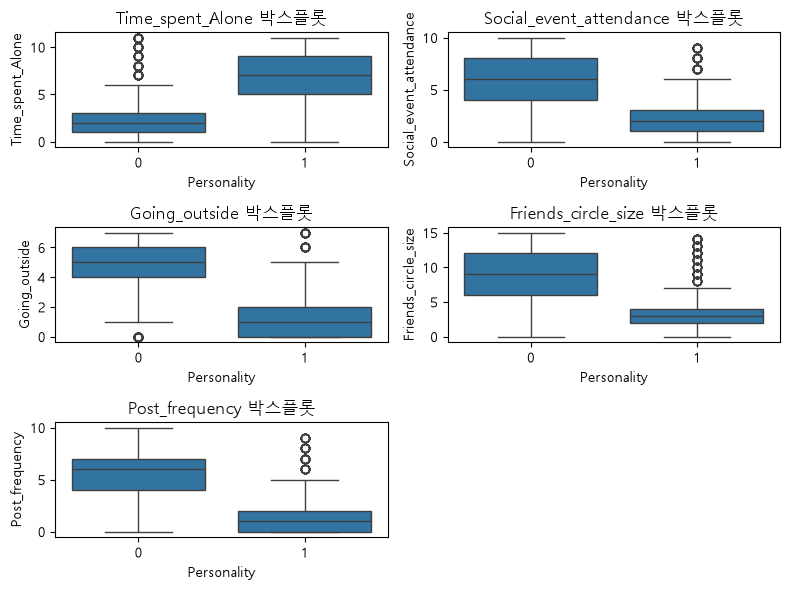

In [25]:
plt.figure(figsize=(8, 6))

for i, col in enumerate(nf, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(x=target, y=col, data=df)
    plt.title(f'{col} 박스플롯')

plt.tight_layout()
plt.show()

In [26]:
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(len(X_train), len(X_test), len(y_train), len(y_test))

2320 580 2320 580


학습셋 정확도: 0.9371
학습셋 정밀도: 0.9299
학습셋 재현율: 0.9414
학습셋 F1: 0.9356
------------
테스트셋 정확도: 0.9172
테스트셋 정밀도: 0.8953
테스트셋 재현율: 0.9397
테스트셋 F1: 0.9170
              precision    recall  f1-score   support

   Extrovert       0.94      0.90      0.92       298
   Introvert       0.90      0.94      0.92       282

    accuracy                           0.92       580
   macro avg       0.92      0.92      0.92       580
weighted avg       0.92      0.92      0.92       580



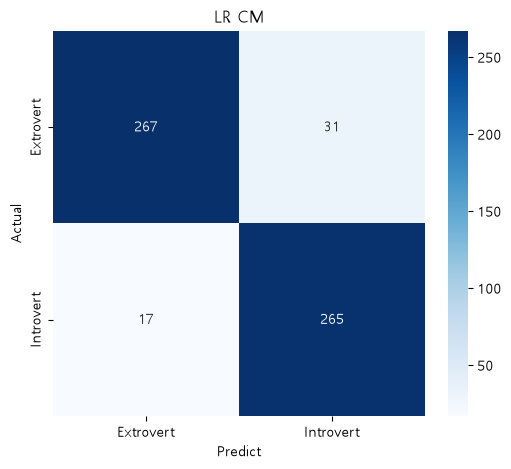

In [27]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)

y_pred_train = lr.predict(X_train)
y_pred = lr.predict(X_test)


print(f'학습셋 정확도: {accuracy_score(y_train, y_pred_train):.4f}')
print(f'학습셋 정밀도: {precision_score(y_train, y_pred_train):.4f}')
print(f'학습셋 재현율: {recall_score(y_train, y_pred_train):.4f}')
print(f'학습셋 F1: {f1_score(y_train, y_pred_train):.4f}')
print("------------")
print(f'테스트셋 정확도: {accuracy_score(y_test, y_pred):.4f}')
print(f'테스트셋 정밀도: {precision_score(y_test, y_pred):.4f}')
print(f'테스트셋 재현율: {recall_score(y_test, y_pred):.4f}')
print(f'테스트셋 F1: {f1_score(y_test, y_pred):.4f}')

print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
labels = le.classes_

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predict')
plt.ylabel('Actual')
plt.title('LR CM')
plt.show()

학습셋 정확도: 0.9841
학습셋 정밀도: 0.9731
학습셋 재현율: 0.9947
학습셋 F1: 0.9838
------------
테스트셋 정확도: 0.8983
테스트셋 정밀도: 0.8912
테스트셋 재현율: 0.9007
테스트셋 F1: 0.8959


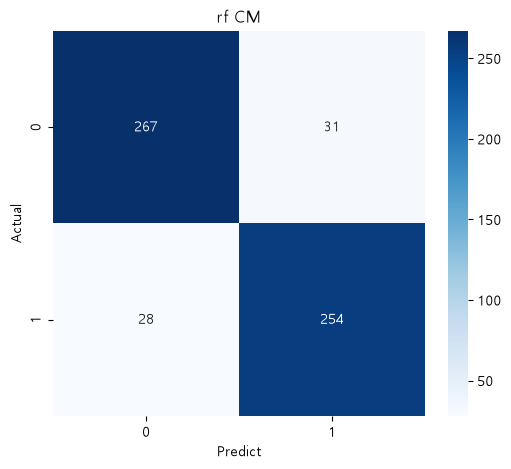

In [28]:
rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train, y_train)

y_pred_train = rfc.predict(X_train)
y_pred = rfc.predict(X_test)


print(f'학습셋 정확도: {accuracy_score(y_train, y_pred_train):.4f}')
print(f'학습셋 정밀도: {precision_score(y_train, y_pred_train):.4f}')
print(f'학습셋 재현율: {recall_score(y_train, y_pred_train):.4f}')
print(f'학습셋 F1: {f1_score(y_train, y_pred_train):.4f}')
print("------------")
print(f'테스트셋 정확도: {accuracy_score(y_test, y_pred):.4f}')
print(f'테스트셋 정밀도: {precision_score(y_test, y_pred):.4f}')
print(f'테스트셋 재현율: {recall_score(y_test, y_pred):.4f}')
print(f'테스트셋 F1: {f1_score(y_test, y_pred):.4f}')

# print(classification_report(y_test, y_pred, target_names=rf.classes_))

cm = confusion_matrix(y_test, y_pred)
labels = rfc.classes_

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predict')
plt.ylabel('Actual')
plt.title('rf CM')
plt.show()

RF 과적합 의심. HP 튜닝 필요

In [29]:
lr.coef_

array([[-0.01399852, -0.02472014, -0.07613103,  0.0482877 , -0.09712297,
         2.41598597,  2.48520882]])

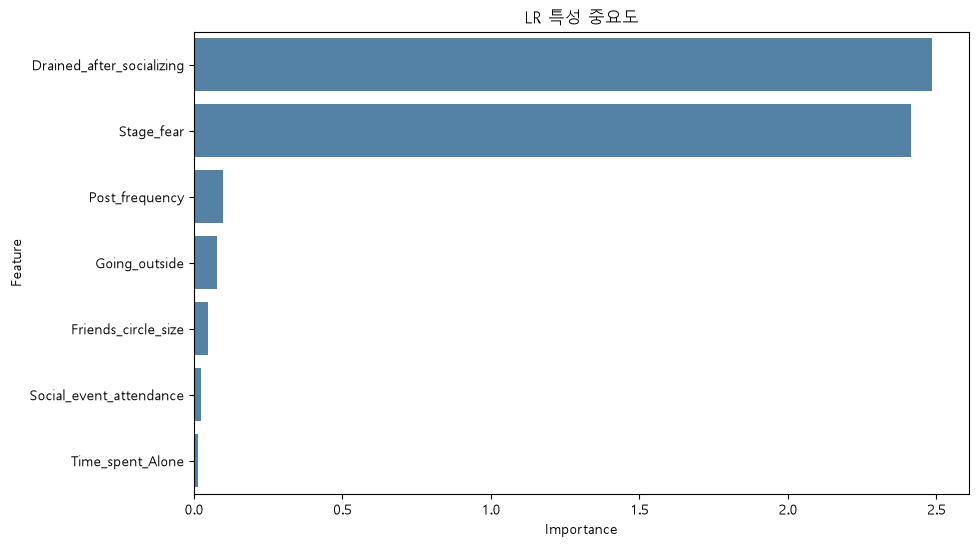

In [30]:
if len(lr.coef_) == 1:
    importances = np.abs(lr.coef_[0])
else:
    importances = np.mean(np.abs(lr.coef_), axis=0)

feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances,
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances, color='steelblue')
plt.title('LR 특성 중요도')
plt.show()

LR는 범주형 변수로만 판단

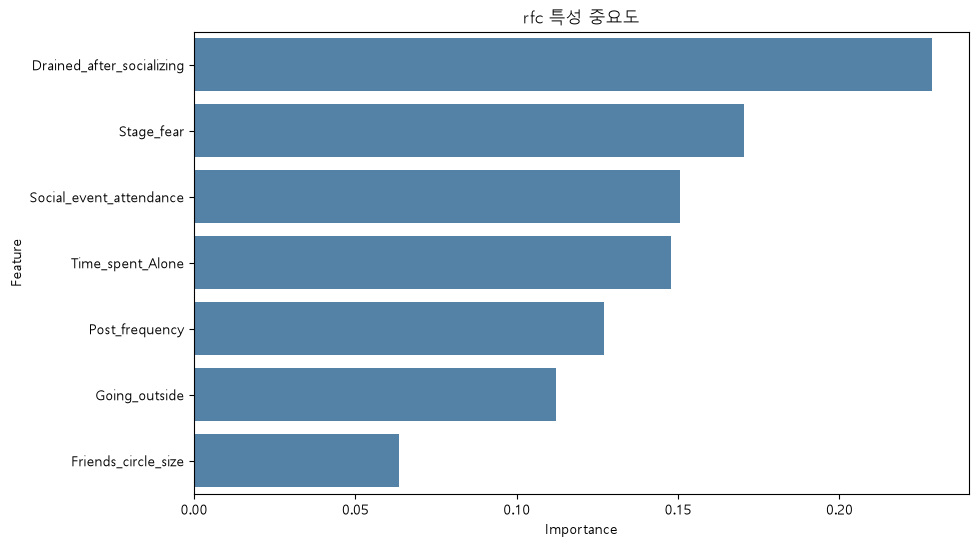

In [31]:
feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rfc.feature_importances_,
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances, color='steelblue')
plt.title('rfc 특성 중요도')
plt.show()

Rf도 범주형 변수 최중요로 판단, 수치형 변수도 적절 중요도 판단

6. 분류 모델 고도화
- RandomizedSearchCV로 HP 값 수정
    - LR
        - C: 규제 강도
        - solver: 최적화 알고리즘
    - RF
        - n_estimators: 트리 개수
        - max_depth: 각 트리 최대 깊이
        - min_samples_split: 노드 나누기 위한 최소 샘플 수

In [32]:
from sklearn.model_selection import ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

models = {
    'logistic': {
        'model': Pipeline([
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(max_iter=1000, random_state=42))
        ]),
        'params': {
            'model__C': np.logspace(-4, 4, 20),
            'model__solver': ['lbfgs', 'liblinear']
        }
    },

    'rf': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 150],
            'max_depth': [None, 10],
            'min_samples_split': [2, 5]
        }
    }
}

results = []
optimized_model = {}

for model_name, mp in models.items():
    n_iter = min(20, len(list(ParameterGrid(mp['params']))))

    clf = RandomizedSearchCV(
        estimator=mp['model'],
        param_distributions=mp['params'],
        n_iter=n_iter,
        cv=3,
        scoring='f1_weighted',
        n_jobs=1,
        random_state=42
    )

    clf.fit(X_train, y_train)

    y_test_pred = clf.best_estimator_.predict(X_test)
    test_f1 = f1_score(y_test, y_test_pred, average='weighted')

    optimized_model[model_name] = clf.best_estimator_

    results.append({
        'model': model_name,
        'best_cv_score': clf.best_score_,
        'test_f1': test_f1,
        'best_params': clf.best_params_
    })

df_results = pd.DataFrame(results).sort_values(by='test_f1', ascending=False)
df_results

,model,best_cv_score,test_f1,best_params
0,logistic,0.938802,0.917248,"{'model__solver': 'lbfgs', 'model__C': 0.00069..."
1,rf,0.938802,0.917248,"{'n_estimators': 100, 'min_samples_split': 2, ..."


In [38]:
clf.best_params_

{'n_estimators': 100, 'min_samples_split': 2, 'max_depth': 10}

7. Pipeline 기반 모델 비교
- Pipeline, ColumnTransformer
    - 전처리, 모델 학습 과정을 하나로 묶어 사용
    - 여러 모델을 같은 전처리 흐름으로 공정하게 비교

In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay

advanced_X = original_df.drop(columns=[target])
advanced_y = original_df[target]

target_encoder = LabelEncoder()
advanced_y_encoded = target_encoder.fit_transform(advanced_y)

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    advanced_X,
    advanced_y_encoded,
    test_size=0.2,
    stratify=advanced_y_encoded,
    random_state=42
)

numeric_features = advanced_X.select_dtypes(include=np.number).columns.tolist()
categorical_features = advanced_X.select_dtypes(include='str').columns.tolist()

print(numeric_features)
print(categorical_features)

['Time_spent_Alone', 'Social_event_attendance', 'Going_outside', 'Friends_circle_size', 'Post_frequency']
['Stage_fear', 'Drained_after_socializing']


8. 전처리 파이프라인 만들기
- 숫자형 변수: 결측값 중앙값으로 채우고, 스케일링 적용
- 범주형 변수: 결측값 최빈값으로 채우고, 원-핫인코딩 적용

In [40]:
def make_preprocessor():
    try:
        onehot = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
    except TypeError:
        onehot = OneHotEncoder(drop='first', handle_unknown='ignore', sparse=False)
    
    numeric_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    categorical_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', onehot)
    ])

    preprocessor = ColumnTransformer([
        ('num', numeric_pipe, numeric_features),
        ('cat', categorical_pipe, categorical_features)
    ])

    return preprocessor

9. 여러 모델 같은 기준으로 비교
- LR, RF, GB(이전 모델 오차 보완하며 학습)

In [41]:
advanced_models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, min_samples_split=2, max_depth=10, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(random_state=42)
}

advanced_results = []
trained_pipelines = {}

for name, estimator in advanced_models.items():
    pipe = Pipeline([
        ('preprocess', make_preprocessor()),
        ('model', estimator)
    ])

    pipe.fit(X_train_raw, y_train_raw)

    y_pred = pipe.predict(X_test_raw)

    advanced_results.append({
        'model': name,
        'accuracy': accuracy_score(y_test_raw, y_pred),
        'precision_weighted': precision_score(y_test_raw, y_pred, average='weighted'),
        'recall_weighted': recall_score(y_test_raw, y_pred, average='weighted'),
        'f1_weighted': f1_score(y_test_raw, y_pred, average='weighted'),
    })

    trained_pipelines[name] = pipe

advanced_results_df = pd.DataFrame(advanced_results).sort_values(by='f1_weighted', ascending=False)
advanced_results_df


,model,accuracy,precision_weighted,recall_weighted,f1_weighted
0,LogisticRegression,0.917241,0.918324,0.917241,0.917248
2,GradientBoosting,0.917241,0.918324,0.917241,0.917248
1,RandomForest,0.915517,0.916457,0.915517,0.915527


In [43]:
df.columns

Index(['Time_spent_Alone', 'Social_event_attendance', 'Going_outside',
       'Friends_circle_size', 'Post_frequency', 'Stage_fear',
       'Drained_after_socializing', 'Personality'],
      dtype='str')

In [44]:
best_model_name = advanced_results_df.iloc[1]['model']
best_pipeline = trained_pipelines[best_model_name]

sample_person = pd.DataFrame([{
    'Time_spent_Alone': 3,
    'Social_event_attendance': 7,
    'Going_outside': 6,
    'Friends_circle_size': 10,
    'Post_frequency': 7,
    'Stage_fear': 'Yes',
    'Drained_after_socializing': 'No'
}])

sample_pred = best_pipeline.predict(sample_person)
sample_pred_name = target_encoder.inverse_transform(sample_pred)

print(f'예측된 성격 유형: {sample_pred_name[0]}, 예측 번호: {sample_pred}')

예측된 성격 유형: Extrovert, 예측 번호: [0]
